## Importing the necessary Libraries


In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_auc_score,f1_score,ConfusionMatrixDisplay
import numpy as np

## Load and Preview the Dataset

Set the CSV file path, load the headerless sonar data into a DataFrame, and display its first five rows. In our dataset, the first 60 columns represent sonar readings, and the last column indicates whether the object is a rock (R) or a mine (M). The headers are not important for our analysis, since the I/P is sound signals. We can still name them as Feature1, Feature2, ..., Feature60, and the last column as Target.

In [19]:
dataPath = "E:\\Veena\\Certificate-Program-in-AIML-IIT-Patna\\ML Projects\\DataSets\\sonar.all-data.csv"
#Why header is None-- Our dataset have no header column. That we need to communicate to pandas. Or else, it will take the first row as 'Header' by default.
columns = [f'Feature_{i}' for i in range(60)]+['Target']
rockVsMineDF = pd.read_csv(dataPath,header=None,names=columns)
rockVsMineDF.head(5)

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59,Target
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## Inspect Dataset Information

Display the DataFrame structure, including the number of entries, columns, data types, and memory usage.

In [20]:
rockVsMineDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_0   208 non-null    float64
 1   Feature_1   208 non-null    float64
 2   Feature_2   208 non-null    float64
 3   Feature_3   208 non-null    float64
 4   Feature_4   208 non-null    float64
 5   Feature_5   208 non-null    float64
 6   Feature_6   208 non-null    float64
 7   Feature_7   208 non-null    float64
 8   Feature_8   208 non-null    float64
 9   Feature_9   208 non-null    float64
 10  Feature_10  208 non-null    float64
 11  Feature_11  208 non-null    float64
 12  Feature_12  208 non-null    float64
 13  Feature_13  208 non-null    float64
 14  Feature_14  208 non-null    float64
 15  Feature_15  208 non-null    float64
 16  Feature_16  208 non-null    float64
 17  Feature_17  208 non-null    float64
 18  Feature_18  208 non-null    float64
 19  Feature_19  208 non-null    float64
 20 

## Generate Descriptive Statistics

Calculate summary statistics such as count, mean, standard deviation, minimum, and maximum for the dataset columns.

In [21]:
rockVsMineDF.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_50,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


## Check for Missing Values

Count all missing values in the DataFrame to verify whether the dataset requires missing-data treatment.

In [22]:
rockVsMineDF.isna().sum().sum()

np.int64(0)

## Check Dataset Dimensions

Determine the number of rows and columns in the DataFrame to understand its overall size.

In [23]:
rockVsMineDF.shape

(208, 61)

## Distribution of the Target Variable

The target variable is stored in column 60, where `R` represents a rock and `M` represents a mine. The `value_counts()` output shows how many observations belong to each class.

Our dataset contains **208 observations**: **111 mines (53.4%)** and **97 rocks (46.6%)**. The classes are fairly balanced, although mines are slightly more frequent than rocks. This small difference is unlikely to create severe class imbalance, but both classes should still be considered when evaluating the model.


In [25]:
rockVsMineDF['Target'].value_counts()

Target
M    111
R     97
Name: count, dtype: int64

## Why Extensive EDA Is Not Required for This Dataset

A complete EDA is not necessary here because this is a small, structured benchmark dataset. The first 60 columns are already numeric sonar measurements, the target column is clearly identified, there are no missing values, and the classes are fairly balanced. Therefore, extensive data cleaning, categorical encoding, or complex outlier treatment may not be needed before applying a model.

This is a **binary classification problem**, not a regression problem, because the target contains two categories: `R` for rock and `M` for mine. **Logistic Regression** is appropriate because it predicts the probability of each class. Ordinary Linear Regression is designed for continuous numeric values and is not the correct choice for this target.

Basic EDA is still important and has already been performed through the data preview, structure check, descriptive statistics, missing-value check, dimension check, and target-distribution check.

## Separate Features and Target

Create `x` with the 60 sonar-measurement features and `y` with the target labels (`R` for rock and `M` for mine).

In [28]:
x=rockVsMineDF.drop(columns=['Target'])
y=rockVsMineDF['Target']

## Preview the Feature Data

Display the first three rows of the feature DataFrame to verify that the target column has been removed correctly.

In [30]:
x.head(3)

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_50,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078


## Preview the Target Data

Display the first three target values to confirm that the labels are stored separately from the input features.

In [32]:
y.head(3)

0    R
1    R
2    R
Name: Target, dtype: str

## Split the Dataset

Split the features and target into training and testing sets. Use 80% of the observations for training, 20% for testing, and `stratify=y` to preserve the class distribution in both sets.

In [40]:
xTrain,xTest,yTrain,yTest = train_test_split(x,y,train_size=0.8,random_state=42,stratify=y)

## Check the Split Sizes

Print the shapes of the training and testing feature and target sets to verify that the split was created as expected.

In [42]:
print(f"Shape of xTrain: {xTrain.shape}")
print(f"Shape of xTest: {xTest.shape}")
print(f"Shape of yTrain: {yTrain.shape}")
print(f"Shape of yTest: {yTest.shape}")


Shape of xTrain: (166, 60)
Shape of xTest: (42, 60)
Shape of yTrain: (166,)
Shape of yTest: (42,)


## Scale the Training Features

Use `StandardScaler` to standardize the training features so that each feature has a comparable scale. Fit the scaler only on the training data to prevent data leakage.

In [ ]:
numCols=xTrain.columns

scalar = StandardScaler()
xTrain[numCols] = scalar.fit_transform(xTrain[numCols])

## Verify Feature Scaling

Display summary statistics for the scaled training features to check that their means are approximately zero and their standard deviations are approximately one.

In [51]:
xTrain.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_50,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59
count,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,...,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02,1.660000e+02
mean,-1.391123e-16,1.070094e-16,1.819161e-16,-6.420567e-17,-1.284113e-16,1.712151e-16,-8.560756e-17,-6.420567e-17,1.150352e-16,-6.688091e-17,...,-6.420567e-17,-6.955614e-17,-2.140189e-17,-5.350472e-17,-1.310866e-16,2.220446e-16,-3.103274e-16,8.025709e-17,-1.658646e-16,-3.210283e-17
std,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,...,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00,1.003026e+00
min,-1.210378e+00,-1.185723e+00,-1.290180e+00,-1.240523e+00,-1.355868e+00,-1.563808e+00,-1.922097e+00,-1.529886e+00,-1.386914e+00,-1.515124e+00,...,-1.249837e+00,-1.172533e+00,-1.375349e+00,-1.301468e+00,-1.126932e+00,-1.302055e+00,-1.333088e+00,-1.126731e+00,-1.233936e+00,-1.129366e+00
25%,-7.081283e-01,-7.116076e-01,-7.293760e-01,-7.322759e-01,-7.370224e-01,-6.195731e-01,-7.058495e-01,-6.465669e-01,-7.082259e-01,-7.008641e-01,...,-6.177565e-01,-6.230063e-01,-8.113404e-01,-7.542180e-01,-6.849600e-01,-6.383971e-01,-7.220305e-01,-6.521676e-01,-6.879720e-01,-6.541135e-01
50%,-2.722351e-01,-2.520804e-01,-2.552066e-01,-1.967399e-01,-2.140825e-01,-1.820009e-01,-1.997244e-01,-2.513898e-01,-2.607912e-01,-1.907299e-01,...,-1.877835e-01,-3.433362e-01,-1.702620e-01,-2.803793e-01,-2.642031e-01,-2.537291e-01,-3.446129e-01,-3.184901e-01,-2.349377e-01,-2.082585e-01
75%,2.895065e-01,2.657995e-01,5.283719e-01,3.026389e-01,6.465473e-01,4.640984e-01,5.356432e-01,4.596262e-01,5.539791e-01,4.996127e-01,...,3.808906e-01,2.994142e-01,5.408796e-01,4.437262e-01,4.288082e-01,3.972475e-01,5.270422e-01,3.266198e-01,4.117009e-01,2.963906e-01
max,4.949330e+00,4.085468e+00,3.815070e+00,3.327564e+00,3.687776e+00,4.645110e+00,4.097657e+00,3.931734e+00,4.360403e+00,3.952107e+00,...,6.707637e+00,5.657304e+00,4.019518e+00,3.250052e+00,5.039455e+00,5.258437e+00,4.993151e+00,5.354028e+00,4.388335e+00,7.356578e+00


## Scale the Test Features

Apply the already-fitted scaler to the test features. The test data is transformed using training-set statistics so the evaluation remains unbiased.

In [52]:
xTest[numCols]=scalar.transform(xTest[numCols])

## Preview the Scaled Test Data

Display the first three rows of the scaled test features to confirm that the transformation was applied successfully.

In [54]:
xTest.head(3)

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_50,Feature_51,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59
96,-0.496474,-0.731869,-1.256145,-1.014029,-0.641116,-0.965862,-1.387877,-0.701377,-0.316344,-0.786473,...,-0.647478,0.888193,2.127811,0.487106,2.012834,-0.710258,-1.063504,-0.459376,0.129038,0.418878
22,-0.871731,0.363864,-0.411458,-0.588329,-0.174711,0.045788,1.872823,1.289952,-1.455816,-0.132094,...,1.888768,0.397544,0.642471,0.086679,1.574398,0.946773,-0.865809,1.201596,0.392340,1.379181
6,0.125904,1.894001,2.750703,2.443418,1.888782,1.106010,-0.785250,0.098062,0.273633,1.143046,...,0.295689,0.672308,2.029723,0.300240,-0.292489,0.929865,0.266444,0.949485,-0.691844,0.771643


## Train the Logistic Regression Model

Create a Logistic Regression classifier and fit it on the scaled training features and their corresponding rock-or-mine labels.

In [56]:
model = LogisticRegression()
model.fit(xTrain,yTrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predict Class Probabilities

Use the trained Logistic Regression model to calculate the probability that each training observation belongs to each class, rock or mine.

In [58]:
model.predict_proba(xTrain)

array([[5.75652090e-01, 4.24347910e-01],
       [9.27843610e-01, 7.21563898e-02],
       [9.93547822e-01, 6.45217768e-03],
       [1.35045619e-01, 8.64954381e-01],
       [7.84456082e-01, 2.15543918e-01],
       [1.44074168e-02, 9.85592583e-01],
       [7.64026754e-01, 2.35973246e-01],
       [9.91835549e-01, 8.16445071e-03],
       [7.13942793e-03, 9.92860572e-01],
       [6.62316757e-04, 9.99337683e-01],
       [6.23697873e-01, 3.76302127e-01],
       [8.36616976e-01, 1.63383024e-01],
       [1.62902827e-01, 8.37097173e-01],
       [1.54499187e-01, 8.45500813e-01],
       [1.80712029e-01, 8.19287971e-01],
       [6.15936588e-01, 3.84063412e-01],
       [2.17049259e-02, 9.78295074e-01],
       [3.27313417e-02, 9.67268658e-01],
       [1.09559393e-02, 9.89044061e-01],
       [6.29121079e-02, 9.37087892e-01],
       [3.55906651e-01, 6.44093349e-01],
       [8.28510433e-01, 1.71489567e-01],
       [7.18130893e-01, 2.81869107e-01],
       [9.15136610e-01, 8.48633895e-02],
       [2.385858

## Predict Training Labels

Use the trained model to predict whether each training observation is a rock or a mine, then display the predicted labels.

In [60]:
yTrainPredict = model.predict(xTrain)
print(yTrainPredict)

['M' 'M' 'M' 'R' 'M' 'R' 'M' 'M' 'R' 'R' 'M' 'M' 'R' 'R' 'R' 'M' 'R' 'R'
 'R' 'R' 'R' 'M' 'M' 'M' 'R' 'M' 'R' 'M' 'M' 'M' 'M' 'M' 'R' 'R' 'R' 'R'
 'M' 'R' 'R' 'R' 'M' 'M' 'M' 'M' 'R' 'R' 'M' 'M' 'M' 'M' 'M' 'M' 'R' 'M'
 'M' 'R' 'M' 'R' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'R' 'M' 'R'
 'M' 'M' 'M' 'M' 'R' 'M' 'M' 'M' 'R' 'M' 'R' 'R' 'M' 'R' 'R' 'R' 'R' 'M'
 'M' 'R' 'M' 'R' 'M' 'R' 'M' 'R' 'M' 'R' 'M' 'R' 'M' 'R' 'R' 'M' 'M' 'M'
 'R' 'M' 'M' 'R' 'M' 'M' 'R' 'R' 'M' 'R' 'R' 'R' 'R' 'M' 'M' 'R' 'M' 'R'
 'M' 'M' 'M' 'R' 'M' 'R' 'R' 'M' 'R' 'M' 'M' 'R' 'R' 'M' 'M' 'R' 'M' 'R'
 'R' 'M' 'M' 'M' 'M' 'R' 'R' 'R' 'R' 'R' 'M' 'M' 'M' 'R' 'R' 'M' 'M' 'R'
 'M' 'R' 'R' 'R']


## Create the Training Confusion Matrix

Compare the actual training labels with the predicted labels. The confusion matrix shows correct predictions and classification errors for both classes.

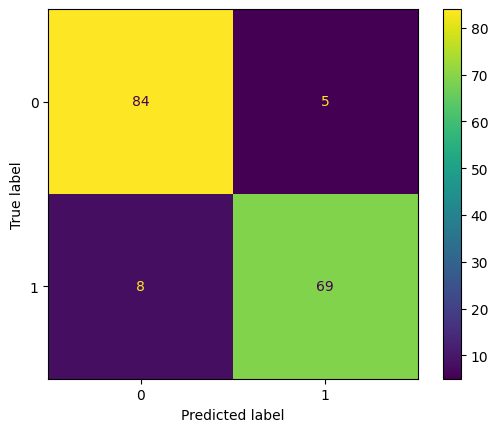

In [73]:
confusionMatrix = confusion_matrix(yTrain,yTrainPredict)
displayCM=ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
displayCM.plot()

## Evaluate Training Accuracy and Precision

Calculate the training accuracy and precision of the Logistic Regression model. Here, `M` is treated as the positive class for the precision calculation.

In [92]:
trainAccuracyScore = accuracy_score(yTrain,yTrainPredict)
print(f"Accuracy Score of Logistic Regression model, on Training data: {trainAccuracyScore:.2%}")

trainPrecision = precision_score(yTrain,yTrainPredict,pos_label='M')
print(f"Precision of Logistic Regression model, on Training data: {trainPrecision:.2%}")

trainRecall = recall_score(yTrain,yTrainPredict,pos_label='M')
print(f"Recall of Logistic Regression model, on Training data: {trainRecall:.2%}")

trainF1Score = f1_score(yTrain,yTrainPredict,pos_label='M')
print(f"F1 Scre of Logistic Regression model, on Training data: {trainF1Score:.2%}")

Accuracy Score of Logistic Regression model, on Training data: 92.17%
Precision of Logistic Regression model, on Training data: 91.30%
Recall of Logistic Regression model, on Training data: 94.38%
F1 Scre of Logistic Regression model, on Training data: 92.82%


## Predict Class Probabilities for Test Data

Use the trained Logistic Regression model to calculate the probability that each test observation belongs to each class, rock or mine.

In [85]:
model.predict_proba(xTest)

array([[1.97904890e-02, 9.80209511e-01],
       [3.31797006e-01, 6.68202994e-01],
       [4.51154354e-01, 5.48845646e-01],
       [5.52376556e-01, 4.47623444e-01],
       [6.48369350e-01, 3.51630650e-01],
       [9.99989652e-01, 1.03479640e-05],
       [9.79541730e-01, 2.04582701e-02],
       [3.21657526e-02, 9.67834247e-01],
       [9.99718432e-01, 2.81568084e-04],
       [9.94344215e-03, 9.90056558e-01],
       [1.83258592e-02, 9.81674141e-01],
       [9.76378485e-01, 2.36215151e-02],
       [2.53692438e-02, 9.74630756e-01],
       [5.23350702e-02, 9.47664930e-01],
       [6.70843320e-01, 3.29156680e-01],
       [7.50604342e-02, 9.24939566e-01],
       [9.88871235e-01, 1.11287653e-02],
       [9.97563265e-01, 2.43673518e-03],
       [9.86651038e-01, 1.33489615e-02],
       [8.52066029e-01, 1.47933971e-01],
       [9.99414892e-01, 5.85107837e-04],
       [8.74696220e-01, 1.25303780e-01],
       [7.87833794e-01, 2.12166206e-01],
       [5.14607919e-01, 4.85392081e-01],
       [4.624717

## Predict Test Labels

Use the trained model to predict whether each test observation is a rock or a mine, then display the predicted labels.

In [86]:
yTestPredict = model.predict(xTest)
print(yTestPredict)

['R' 'R' 'R' 'M' 'M' 'M' 'M' 'R' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'R' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'R' 'R' 'M' 'M' 'M' 'R' 'R' 'M' 'R' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'R']


## Create the Test Confusion Matrix

Compare the actual test labels with the predicted labels. The confusion matrix shows correct predictions and classification errors for the unseen test data.

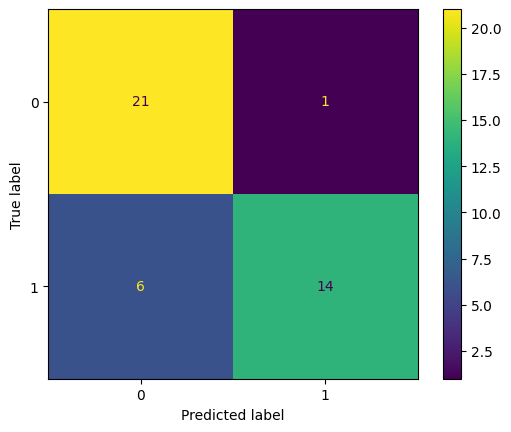

In [87]:
testConfusionMatrix = confusion_matrix(yTest,yTestPredict)
testDisplayCM = ConfusionMatrixDisplay(confusion_matrix=testConfusionMatrix)
testDisplayCM.plot()

## Evaluate Test Accuracy and Precision

Calculate accuracy, precision, recall, and F1 score on the unseen test data. Here, `M` is treated as the positive class so the metrics are consistent with the training evaluation.

In [101]:
testAccuracyScore = accuracy_score(yTest,yTestPredict)
print(f"Accuracy Score of Logistic Regression model, on Test data: {testAccuracyScore:.2%}")

testPrecision = precision_score(yTest,yTestPredict,pos_label='M')
print(f"Precision of Logistic Regression model, on Test data: {testPrecision:.2%}")

testRecall = recall_score(yTest,yTestPredict,pos_label='M')
print(f"Recall of Logistic Regression model, on Test data: {testRecall:.2%}")

testF1Score = f1_score(yTest,yTestPredict,pos_label='M')
print(f"F1 Score of Logistic Regression model, on Test data: {testF1Score:.2%}")

Accuracy Score of Logistic Regression model, on Test data: 83.33%
Precision of Logistic Regression model, on Test data: 77.78%
Recall of Logistic Regression model, on Test data: 95.45%
F1 Score of Logistic Regression model, on Test data: 85.71%


## Predict a New Observation With and Without Scaling

Provide one new sonar observation containing 60 feature values. Convert the input tuple into a NumPy array and reshape it to `(1, 60)`, representing one observation with 60 features.

The first prediction uses the raw input values without scaling. The second prediction applies the same `StandardScaler` fitted on the training data before calling the model. Comparing both results demonstrates why new data should receive the same preprocessing as the training data. The scaled prediction is the valid result for this model because Logistic Regression was trained on standardized features.

In [ ]:
inputData = (0.0091,0.0213,0.0206,0.0505,0.0657,0.0795,0.0970,0.0872,0.0743,0.0837,0.1579,0.0898,0.0309,0.1856,0.2969,0.2032,0.1264,0.1655,0.1661,0.2091,0.2310,0.4460,0.6634,0.6933,0.7663,0.8206,0.7049,0.7560,0.7466,0.6387,0.4846,0.3328,0.5356,0.8741,0.8573,0.6718,0.3446,0.3150,0.2702,0.2598,0.2742,0.3594,0.4382,0.2460,0.0758,0.0187,0.0797,0.0748,0.0367,0.0155,0.0300,0.0112,0.0112,0.0102,0.0026,0.0097,0.0098,0.0043,0.0071,0.0108)

inputDataNp = np.asarray(inputData, dtype=float)
inputDataNp = inputDataNp.reshape(1, -1)
finalPrediction = model.predict(inputDataNp)
print(f"Final prediction w/o applying scaling: {'Rock' if finalPrediction[0] == 'R' else 'Mine'}")
inputDataNp_Scaled = scalar.transform(inputDataNp)
finalPredictionScaled = model.predict(inputDataNp_Scaled)
print(f"Final prediction with applying scaling: {'Rock' if finalPredictionScaled[0] == 'R' else 'Mine'}")

Final prediction w/o applying scaling: Mine
Final prediction with applying scaling: Rock


c:\Users\kodimala.veena\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\kodimala.veena\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\kodimala.veena\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


: 